### Imports

In [2]:
import os
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
from astropy.constants import c, k_B, R_earth
import src.read_database as read_database
import src.map_properties as map_properties
import src.satellite_properties as satellite_properties
import src.store_FOV_indices as store_FOV_indices
import src.Friis as Friis
import src.power_3D_cube as power_3D_cube
import time
#%matplotlib inline   

### Read FM Transmitter Database 

In [3]:
start_time=time.time()
#n = str(input("Enter the number of countries to include"))
n="All"
df = read_database.read_FM_database(countries=read_database.get_countries(n))

/home/bharat/rfi/STARFIRE/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)
/home/bharat/rfi/STARFIRE/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)


### Define frequency range  

In [4]:
#START : starting frequency in MHz
#STOP : stopping frequency in MHz
#FREQ_RES : frequency resolution
START=30
STOP=150
FREQ_RES=1
#---------------------------------------
freq_range = read_database.get_freq_range_manual(START,STOP,FREQ_RES)
df = read_database.extract_common_freq(df, freq_range)

### Define resolution of the Healpy map

In [5]:
# The default value of nside is 16
#nside = int(input("Enter the NSIDE of the healpy map"))
nside = 8
# Create basic HEALPix map information
# - Computes total number of pixels for given NSIDE
# - Generates pixel indices (0 to npix-1)
# - Returns longitude and latitude for each pixel
# All outputs are 1D arrays with one entry per pixel
npix, pix_array, phi, theta = map_properties.get_map(nside)

print(f"The number of pixels for the given NSIDE: {(hp.nside2npix(nside))}")
print(f"Approximate resolution in degrees for given nside {np.degrees(hp.nside2resol(nside)):.2f}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.2f} square degrees")

The number of pixels for the given NSIDE: 768
Approximate resolution in degrees for given nside 7.33
Pixel area: 53.71 square degrees


In [6]:
#beam_pattern=str(input('Enter desired beam pattern:'))
#cos square or sin square
beam_pattern="cos square"

### Allocate pixel number to the Latitude and Longitude of each FM transmitter in the database

In [7]:
# Assign a HEALPix pixel index to each FM transmitter
# - Converts station longitude and latitude to HEALPix pixels
# - Adds the pixel number as a new column in the dataframe
# Used to place real stations onto a HEALPix sky map
df, pixel_indices = read_database.allocate_pixel_num(nside, df)


### Define altitude of the satellite orbit 

In [ ]:
#altitudes = satellite_properties.get_altitudes() #input format: alt1 alt2 alt3 (example:650 705 36000)
#Enter 3 altitudes for the satellite calculations
altitudes = satellite_properties.get_altitudes_manual(650,705,384400-2000)

### Calculation of Elevation angle

In [9]:
# Computes elevation angle between two Earth locations
# - Assumes the satellite is directly above one pixel
# - Calculates angle to another pixel on Earth
# - Repeats this for all pixel pairs and altitudes
# This is an all-to-all pixel calculation
elev_angle = satellite_properties.calc_elev_angle_fast(npix, phi, theta, altitudes)

###  Calculation of Field of view (FOV) and Radius of the FOV of the satellite

In [10]:
# Calculates the maximum field of view of a nadir-pointing satellite
# - Assumes visibility down to the Earth horizon (0° elevation)
# - Returns the full angular width of Earth seen by the satellite
# One FOV value is returned for each satellite altitude
FOV = satellite_properties.calc_field_of_view(altitudes)

The Field of view of the satellite at a height of 650.00 km is 2.27 radians
The Field of view of the satellite at a height of 705.00 km is 2.24 radians
The Field of view of the satellite at a height of 384400.00 km is 0.03 radians


In [11]:
# Calculates the central angle of Earth visible from the satellite
# - Central angle defines how far from nadir the satellite can see
# - This angle is also the radius of the visible Earth disc (in radians)
# Returns one central angle and FOV radius per altitude
Central_angle, Rad_of_FOV = satellite_properties.calc_central_angle(altitudes)

The Radius of the Field of View for a height of 650.00 km in radians is 0.43
The Radius of the Field of View for a height of 705.00 km in radians is 0.45
The Radius of the Field of View for a height of 384400.00 km in radians is 1.55


# Create power cube 

In [12]:
#Stores indices of the pixel numbers that are inside the circle/disc(FOV)
disc = store_FOV_indices.get_disc(nside, phi, theta, Rad_of_FOV, pix_array)
#disc is a 2-D structure where each “pixel” contains a list of all pixels it covers.
#pix_array, array of fm Tx postion on healpy map
pix_common = store_FOV_indices.get_common_pix(pix_array, Rad_of_FOV, disc, df)
del disc
#pix_common is a 2-D array, and each element of that array is a list (1-D array) of FM transmitter pixel numbers.
# This function identifies FM transmitters that lie inside the satellite field of view.
# For each possible satellite ground pixel and each satellite altitude:
# - pix_common contains pixels inside the FOV
# - pixel_indices contains pixels where FM transmitters exist
# The function compares these two and keeps only the FM transmitter pixels
# that fall within the FOV.
#
# Variables:
# pixel_indices : 1D array of HEALPix pixel numbers where FM transmitters are located
# pix_common    : 2D array; each element is a list of pixels inside the satellite FOV
# Rad_of_FOV    : 1D array of satellite FOV radii (one per altitude)
# found_common  : 2D array; each element is a list of FM transmitter pixels
#                 visible inside the satellite FOV

found_common = store_FOV_indices.get_common_Tx_fast(pixel_indices, pix_common, Rad_of_FOV)
del pix_common

# Calculates FM interference power received by a satellite using the Friis equation.
# For each FM transmitter and satellite altitude, the received power is computed
# assuming free-space propagation and isotropic antennas.
#
# df              : FM transmitter database (EIRP, frequency, etc.)
# altitudes       : Satellite altitudes in km
# Rx_Power_in_K   : Received power as equivalent noise temperature (Kelvin)

Rx_Power_in_Kelvin = Friis.calc_Friis_fast(df, altitudes)[2]
# Builds FM power dataframes for the satellite field of view (FOV).
# For each satellite pixel position and altitude:
# - Selects FM transmitters inside the FOV
# - Applies the antenna beam pattern using elevation angle
# - Sums received FM power by frequency
#
# Variables:
# Rx_Power_in_Kelvin : 2D array of received FM power (transmitter × altitude)
# df                 : FM transmitter database (pixel number, frequency)
# found_common       : 2D array of FM transmitter pixels inside the FOV
# Rad_of_FOV         : Satellite FOV radius for each altitude
# elev_angle         : Elevation angles between satellite and transmitters
# beam_pattern       : Antenna beam pattern model
# df_fov             : 2D array of DataFrames, one per satellite pixel and altitude
# i : altitude index (which satellite height / FOV size)
# j : satellite ground pixel position (where the satellite is overhead)
# k : index of an FM transmitter inside that FOV
df_fov = power_3D_cube.get_dataframe_fov(Rx_Power_in_Kelvin, df, found_common, Rad_of_FOV, elev_angle,beam_pattern)
del Rx_Power_in_Kelvin, found_common

# This function builds a 3D cube of received FM power.
# The cube dimensions are:
#   altitude × satellite pixel position × frequency
#
# For each satellite altitude (k),
# for each satellite ground pixel position (m),

# and for each frequency (l):
# - It looks inside the corresponding df_fov DataFrame
# - Checks whether FM power exists at that frequency
# - Stores the received FM power value
# - Stores 0 if no transmitter exists at that frequency
#
# Index meaning:
# k : altitude index (defines FOV size)
# m : satellite pixel position (where the satellite is overhead)
# l : frequency index
#
# Variables:
# npix         : total number of HEALPix pixels
# Rad_of_FOV   : array of satellite FOV radii (one per altitude)
# freq_range  : list of frequencies to define the frequency axis
# df_fov      : 2D array of DataFrames [pixel position][altitude]
# power_output: 3D array [altitude][pixel][frequency] storing FM power

power_output = power_3D_cube.get_power_output(npix, Rad_of_FOV, freq_range, df_fov)
del df_fov
end_time=time.time()

In [13]:
execution_time = end_time - start_time

print(f"Execution time: {execution_time/3600} hours")

Execution time: 0.02478237834241655 hours


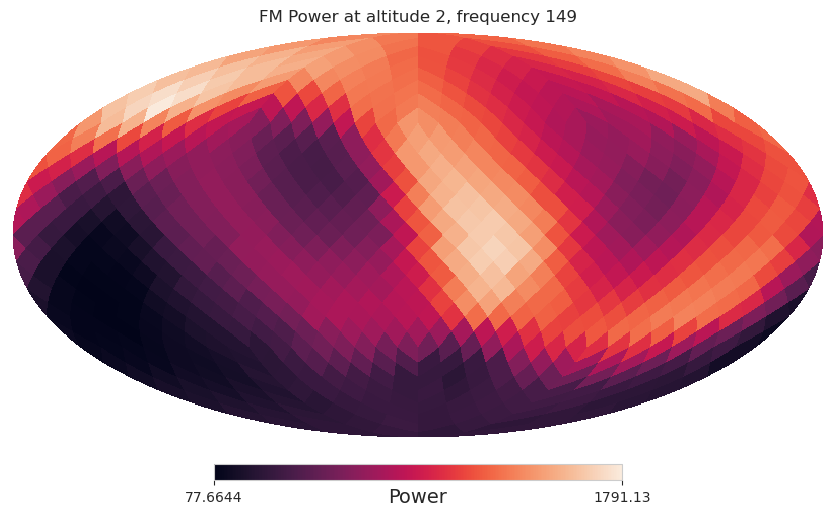

In [56]:
freq_sel=99
# choose altitude and frequency indices
k = 2   # altitude index
l = 119  # frequency index

healpy_map = power_output[k, :, freq_sel-30]

hp.mollview(
    healpy_map,
    title=f"FM Power at altitude {k}, frequency {freq_range[l]}",
    unit="Power"
)

plt.show()

In [ ]:

k = 2

for freq_sel in range(120):
    freq_mhz = 30 + freq_sel  # 30–149 MHz (adjust if needed)

    healpy_map = power_output[k, :, freq_sel]

    filename = f"{freq_mhz}MHz.txt"
    np.savetxt(filename, healpy_map)


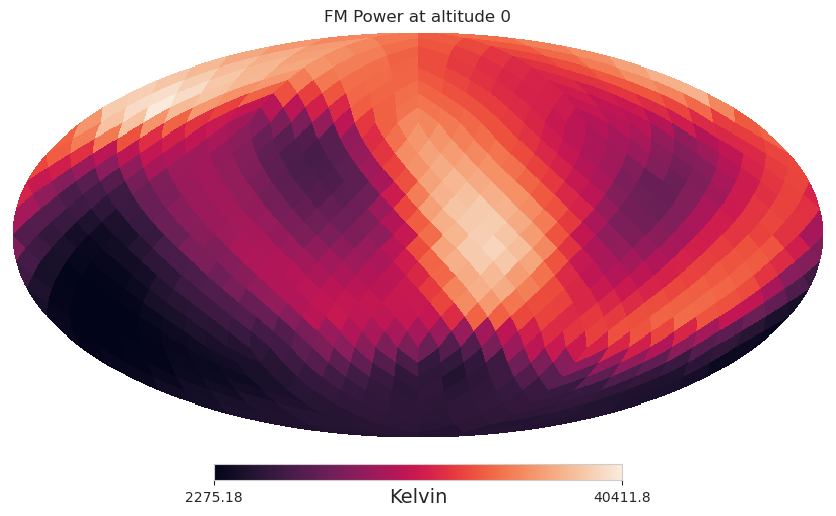

In [15]:
k=2
healpy_map = power_output[k, :, :].sum(axis=1)
hp.mollview(
    healpy_map,
    title=f"FM Power at altitude {0}",
    unit="Kelvin"
)

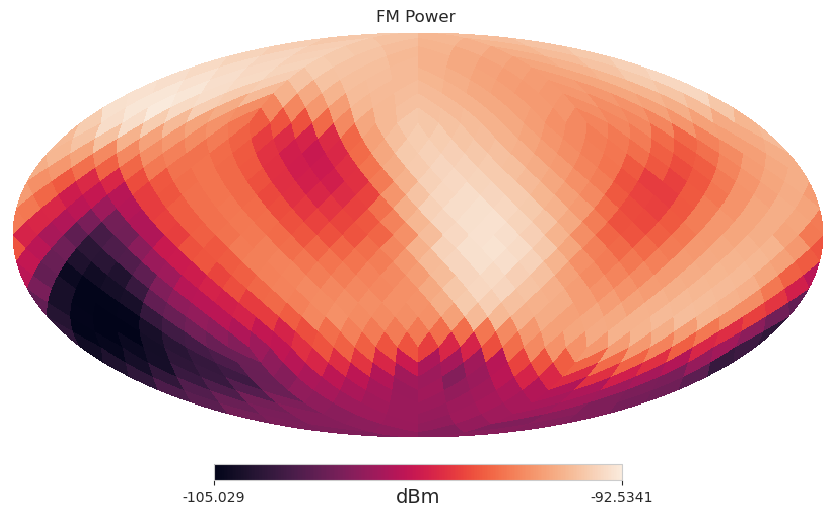

In [ ]:
idx = 2

healpy_map_K = power_output[idx, :, :].sum(axis=1)

healpy_map_K = np.asarray(healpy_map_K, dtype=np.float64)
k_B = 1.380649e-23  
B = 1e6             
power_watts = k_B * healpy_map_K * B
power_dBm = 10.0 * np.log10(power_watts/1e-3) 

hp.mollview(
    power_dBm,
    title="FM Power ",
    unit="dBm"
)

In [24]:
10*np.log10(np.sum(power_watts))+30

np.float64(-67.07869904428097)

## Plot  Spectrum 

<b> The first index represents altitude of the satellite <b>\
<b> The second index represents location of the satellite(pixel number) <b>\
<b> The third index represents range of frequencies <b>

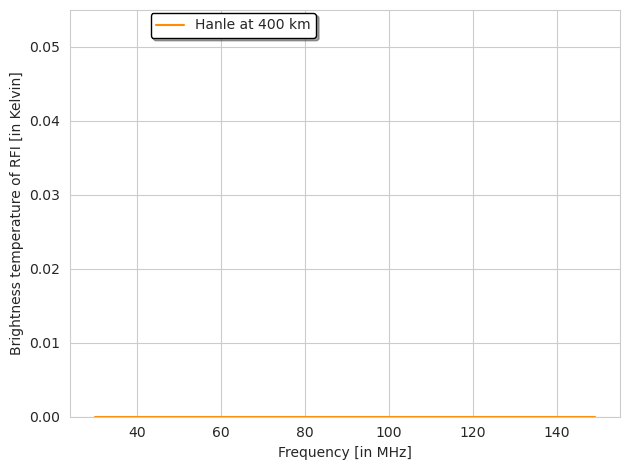

In [ ]:
# # sns.set_style("darkgrid")
# sns.set(rc={"xtick.bottom": True, "ytick.left": True,
#             "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
munpix=hp.ang2pix(nside, 79.00119940706838,32.79051336948348,lonlat=True)
plt.plot(freq_range,np.zeros(len(freq_range)), label='Hanle at 400 km', color='darkorange') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
# plt.yscale('log')
plt.ylim(bottom=0)
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/IC_RFIspec.pdf',dpi=600,bbox_inches='tight')


# Orbit evaluation

In [ ]:
# Predefine constants
deltaT=8.640869140625
thresholdFOM=54 # threshold FOM for radio quiet zones
tot_band=freq_range[-1]-freq_range[0]

## RFI assessment in polar orbit

### FOM map for landsat (alt: 705 km)

In [ ]:
# this cell calculates FOM of each pixel over an altitude of 705 km
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[1,i,:]>300])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band
    

In [ ]:
polon=np.load('./ground_tracks/polar_GT/longitude.npy')
polat=np.load('./ground_tracks/polar_GT/latitude.npy')
polsunlit=np.load('./ground_tracks/polar_GT/sunlit.npy')

In [ ]:
saalon=np.linspace(-90,40,100)
saalat=np.linspace(-50,0,100)
blon,blat=np.meshgrid(saalon,saalat)
bpix=hp.ang2pix(nside,blon,blat,lonlat=True)

In [ ]:
FOM_map[bpix]=0 # Set SAA pixels to 0 FOM

In [ ]:
nbin=int(STOP-START)
FOMtime1=np.zeros(nbin) # define FOM bins of width 1 MHz 
for i in range(len(polat)): # i is a day of OP
    for j in range(len(polat[0])): # j is each ground track coord of that sliced day. (10000 points)
        orbpix=hp.ang2pix(nside,polon[i,j],polat[i,j],lonlat=True) # get pixel of coord
        fomval=int(FOM_map[orbpix]) # obtain FOM value in integer format
        if polsunlit[i,j]==True: 
            FOMtime1[fomval]+=0 # Does not count the FOM if it is sunlit.
        else:
            FOMtime1[fomval]+=deltaT # Adds deltaT if the point is not sunlit, as it spends deltaT time at that
                                     # point.

In [ ]:
np.sum(FOMtime1)/3600

np.float64(2964.05813937717)

In [ ]:
(FOMtime1[-1])/3600 # Total time spent in highest FOM bin per year in hours

np.float64(156.88938069661458)

### Max uninterrupted RFI free time per day

In [ ]:
dailymax=[]
dailytotal=[]
for h in range(polat.shape[0]):
    oneslice=polsunlit[h,:]
    count=0
    foms=[]
    for k in range(len(oneslice)):
        if oneslice[k-1]==oneslice[k]==False:
            pix=hp.ang2pix(nside,polon[h,k],polat[h,k],lonlat=True)
            foms.append(int(FOM_map[pix]))
            valz=[]
            for i in range(len(foms)-1):
                if foms[i+1]==foms[i]>=thresholdFOM:
                    count+=1
                else:
                    valz.append(count*(deltaT/60))
                    count=0
    dailymax.append(max(valz)) 
    dailytotal.append(sum(valz))




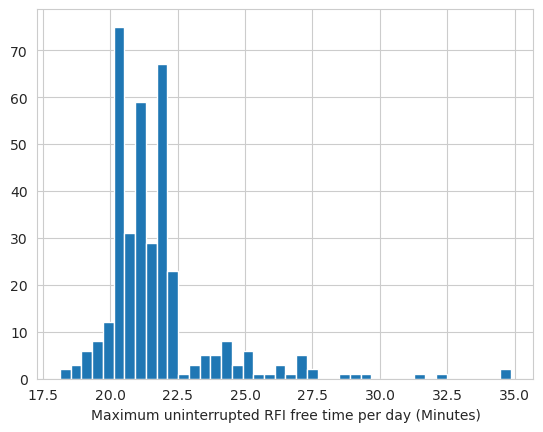

In [ ]:
from src2.FDrule import FDrule
sns.set_style('whitegrid')
plt.hist(dailymax,bins=FDrule(dailymax))
plt.xlabel('Maximum uninterrupted RFI free time per day (Minutes)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/polar_unint.pdf',dpi=600,bbox_inches='tight')
plt.show()

### RFI lines over good regions

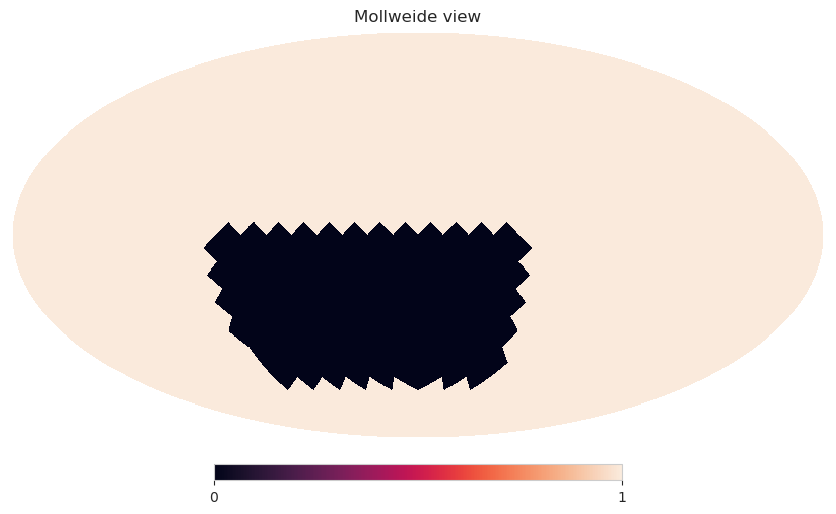

In [ ]:
goodpix=np.where(FOM_map>54)
newfom=np.zeros(hp.nside2npix(nside))
newfom[goodpix]+=1
hp.mollview(newfom,flip='geo')

In [ ]:
goodpix=np.array(goodpix)

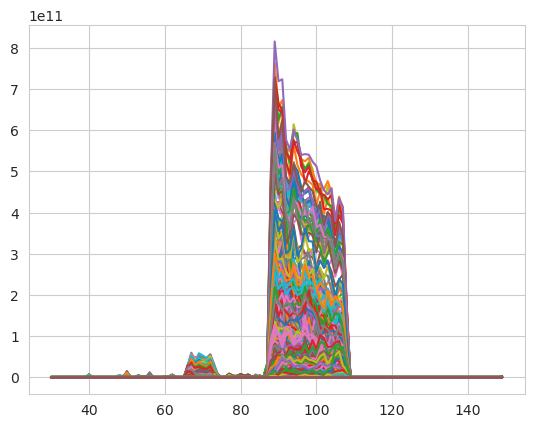

In [ ]:
goodpix=np.array(goodpix)[0]
num=[]
for i in goodpix:
    lines=power_output[1,i,:]
    num.append(np.sum(lines>300))
    plt.plot(freq_range,lines)
plt.show()

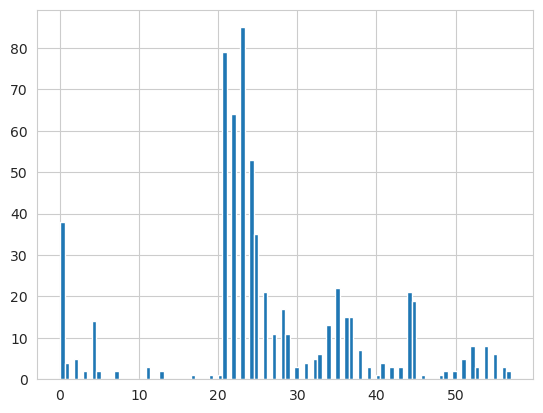

In [ ]:
plt.hist(num,bins=100)
plt.show()

In [ ]:
num=np.array(num)

In [ ]:
len(num[num==0])

38

In [ ]:
#OWFOM=np.zeros(hp.nside2npix(nside))
#time=np.zeros(np.shape(OWFOM))
#for i in range(len(polat)):
#    for j in range(len(polat[0])):
#        pix=hp.ang2pix(nside,polon[i,j],polat[i,j],lonlat=True)
#        time[pix]+=deltaT/3600

npix = hp.nside2npix(nside)
time = np.zeros(npix)
pix = hp.ang2pix(nside, polon, polat, lonlat=True)
np.add.at(time, pix, deltaT / 3600)        

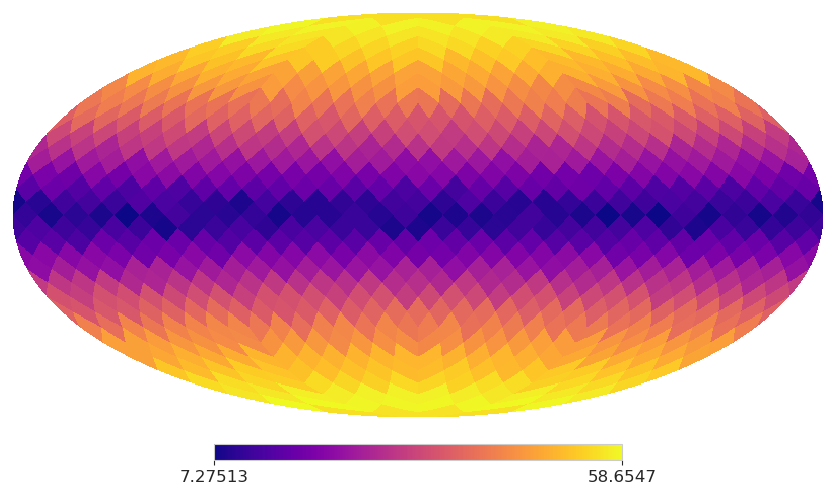

In [ ]:
plt.rcParams.update({'font.size':12})

hp.mollview(time,flip='geo',cmap='plasma',norm='hist',title='',)
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/timeHM_polar.pdf',dpi=600)
plt.show()


In [ ]:
np.max(power_output[0,:,:])*1e-10

94.02348038891557

## RFI assessment in equatorial orbit

### FOM map for AstroSAT (alt: 650km)

In [ ]:
# this cell calculates FOM of each pixel over an altitude of 705 km
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[0,i,:]>300])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band
    

In [ ]:
FOM_map[bpix]=0

In [ ]:
equilon=np.load('ground_tracks/equi_GT/longitude.npy')
equilat=np.load('ground_tracks/equi_GT/latitude.npy')
equisunlit=np.load('ground_tracks/equi_GT/sunlit.npy')

ValueError: x and y must have same first dimension, but have shapes (55,) and (120,)

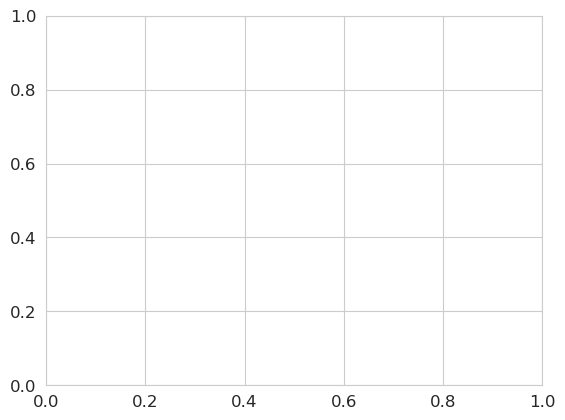

In [ ]:


#FOMtime=np.zeros(nbin)
#for i in range(len(equilat)):
#    for j in range(len(equilat[0])):
#        orbpix=hp.ang2pix(nside,equilon[i,j],equilat[i,j],lonlat=True)
#        fomval=int(FOM_map[orbpix])
#        if equisunlit[i,j]==True:
#            FOMtime[fomval]+=0
#        else:
#            FOMtime[fomval]+=deltaT


FOMtime = np.zeros(nbin)

# Vectorised HEALPix lookup
orbpix = hp.ang2pix(nside, equilon, equilat, lonlat=True)

# Map orbit pixels → FOM bins
fomval = FOM_map[orbpix].astype(int)

# Only count sunlit samples
dt = deltaT * (~equisunlit)

# Accumulate time per FOM bin
np.add.at(FOMtime, fomval, dt)

fomvals=np.linspace(0,55,55)
plt.plot(fomvals,(FOMtime/3600))
plt.show()

# dailymax=[]
# dailytotal=[]
# for h in range(equilat.shape[0]):
#     oneslice=equisunlit[h,:]
#     count=0
#     foms=[]
#     for k in range(len(oneslice)):
#         if oneslice[k-1]==oneslice[k]==False:
#             pix=hp.ang2pix(nside,equilon[h,k],equilat[h,k],lonlat=True)
#             foms.append(int(FOM_map[pix]))
#             valz=[]
#             for i in range(len(foms)-1):
#                 if foms[i+1]==foms[i]>=thresholdFOM:
#                     count+=1
#                 else:
#                     valz.append(count*(deltaT/60))
#                     count=0
#     dailymax.append(max(valz))            
#     dailytotal.append(sum(valz))


In [ ]:
FOMtime[-1]/3600

np.float64(42.46267110188802)

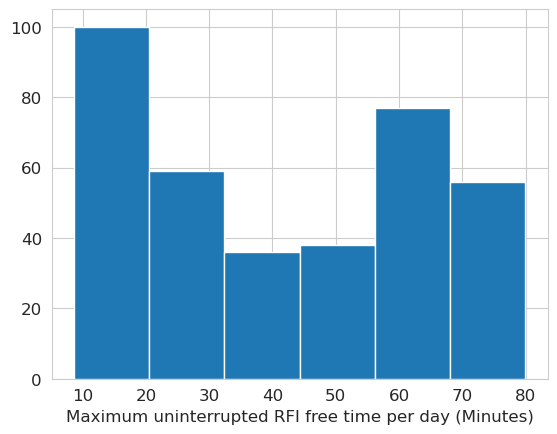

In [ ]:
from src2.FDrule import FDrule
sns.set_style('whitegrid')
plt.hist(dailymax,bins=FDrule(dailymax))
plt.xlabel('Maximum uninterrupted RFI free time per day (Minutes)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/equi_unint.pdf',dpi=600,bbox_inches='tight')
plt.show()

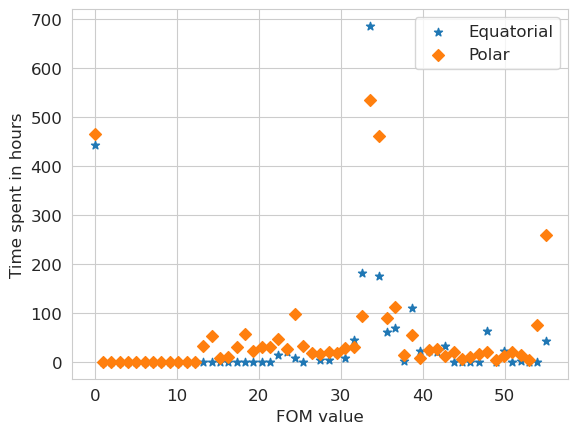

In [ ]:
# compare the two orbits:
plt.scatter(fomvals,FOMtime/3600,label='Equatorial',marker='*')
plt.scatter(fomvals,FOMtime1/3600,label='Polar',marker='D')
plt.ylabel('Time spent in hours')
plt.xlabel('FOM value')
# plt.xlim(left=10)
plt.legend()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/orbitcomp.pdf',dpi=600,bbox_inches='tight')
plt.show()

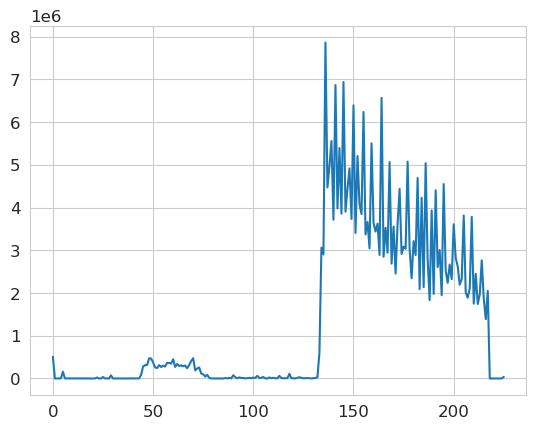

In [ ]:
plt.plot(power_output[2,20,:])
plt.show()

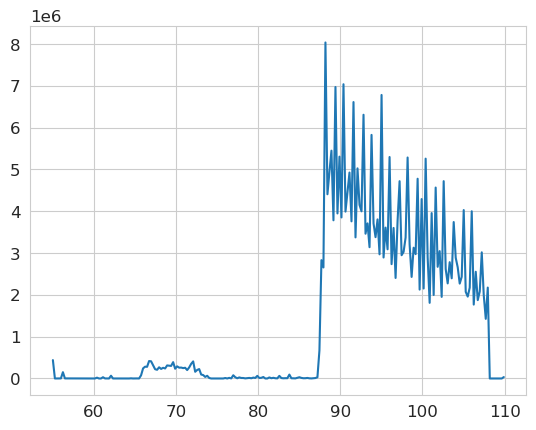

In [ ]:
plt.plot(freq_range,power_output[2,10,:])

In [ ]:
eqlon=np.arange(-180,180,1)
eqlat=np.zeros(eqlon.shape)
eq_traj_pix=hp.ang2pix(nside,eqlon,eqlat,lonlat=True)


In [ ]:
# waterfall plots of pixel vs frequency and power as the weight
x=freq_range
y=eqlon
xx,yy=np.meshgrid(x,y)
power_val=np.zeros((len(eq_traj_pix),len(x)))
for i in range(len(x)):
    for index,j in enumerate(eq_traj_pix):
        power_val[index,i]+=power_output[2,j,i]


In [ ]:
sums=[]
for i in range(360):
    sums.append(np.sum(power_val[i,:]))

In [ ]:
np.where(sums==min(sums))

(array([321, 322, 323, 324, 325, 326]),)

Text(0.5, 0, 'Frequency(MHz)')

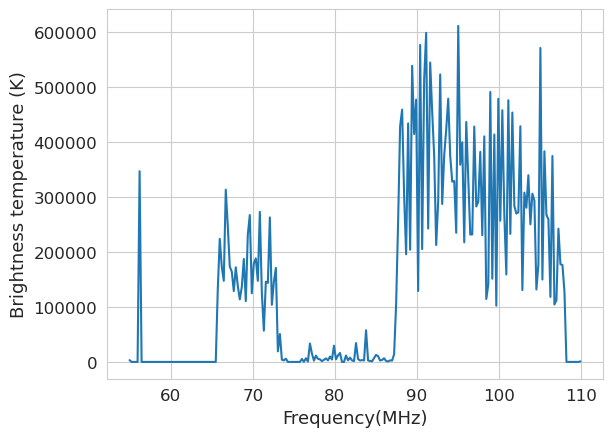

In [ ]:
plt.plot(freq_range,power_val[324,:])
plt.ylabel('Brightness temperature (K)',fontsize=13)
plt.xlabel('Frequency(MHz)',fontsize=13)
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/L2_slice.pdf',dpi=600,bbox_inches='tight')


In [ ]:
power_val[324,:]

array([3.27257477e+03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.47227889e+05, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.30685225e+05, 2.24051282e+05, 1.73695684e+05, 1.47707530e+05,
       3.13591433e+05, 2.47847660e+05, 1.73447900e+05, 1.64425348e+05,
       1.28989325e+05, 1.72324463e+05, 1.38427440e+05, 1.13862983e+05,
      

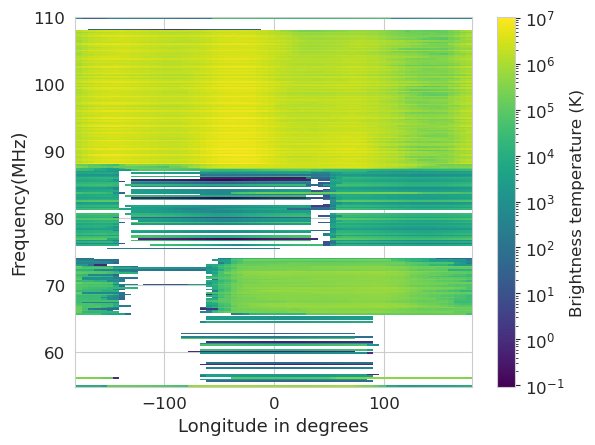

In [ ]:
plt.pcolormesh(yy,xx,power_val,cmap='viridis',norm='log',rasterized=True)
plt.colorbar(label='Brightness temperature (K)')
plt.xlabel('Longitude in degrees',fontsize=13)
plt.ylabel('Frequency(MHz)',fontsize=13)
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/L2_WF.pdf',dpi=600,bbox_inches='tight')
plt.show()

## Geosynchronous orbit

### Alt = 36000 km

In [ ]:
# FOM_map=np.zeros(hp.nside2npix(nside))
# for i in range(len(FOM_map)):
# 	num_of_rfi_chan=len(freq_range[power_output[2,i,:]!=0])
# 	rfi_band=0.244*num_of_rfi_chan 
# 	usable_band=tot_band-rfi_band
# 	FOM_map[i]+=usable_band

In [ ]:
# # open TLE archive
# file=open('../TLE_files/NSS.txt')
# content=file.read()
# ts = load.timescale()
# eph=load('de421.bsp')

In [ ]:
# lineone=[]
# linetwo=[]
# num=2000
# year=np.zeros(num)
# month=np.zeros(num)
# days=np.zeros((num))
# hour=np.zeros((num))
# minute=np.zeros((num))
# second=np.zeros((num))
# for i in range(2000):
#     line11=(content[((2*i)*70):((2*i)*70)+69])
#     line22=(content[((2*i+1)*70):((2*i+1)*70)+69])
#     sate=EarthSatellite(line11,line22,'Landsat7',ts)
# #     print(sate)
#     lineone.append(line11)
#     linetwo.append(line22)
#     year=sate.epoch.utc.year
#     month=sate.epoch.utc.month
#     day=sate.epoch.utc.day
#     days[i]+=day
#     if year==1999.0:
#         if month==11.0:
#             if day==20.0:
#                    break
    
    
    

In [ ]:
# uniq_idx=[]
# for i in range(len(lineone)):
#     if i>0:
#         if days[i]!=days[i-1]:
#             uniq_idx.append(i)
        
   

In [ ]:
# subpoints=[]
# sunlit=[]
# t11=[]
# for idx,i in enumerate(uniq_idx):
#     if idx==0:
#         line1=lineone[i]
#         line2=linetwo[i]
#         satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
#         print(satellite)
#         tz = pytz.timezone('UTC')
#         st=satellite.epoch.utc
#         dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
#         t0 = ts.utc(dt)
#         t1 = ts.utc(dt + relativedelta(hours=24))
#         t11.append(t1)
#         timescales = ts.linspace(t0,t1, 10000)

#         geocentrics = satellite.at(timescales)
#         sunlit.append(geocentrics.is_sunlit(eph))
#         subpoints.append(wgs84.subpoint_of(geocentrics))
#     else:
#         line1=lineone[i]
#         line2=linetwo[i]
#         satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
#         print(satellite)
#         tz = pytz.timezone('UTC')
#         st=t11[idx-1].utc
#         dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
#         t0 = ts.utc(dt)
#         t1 = ts.utc(dt + relativedelta(hours=24))
#         t11.append(t1)
#         timescales = ts.linspace(t0,t1, 10000)

#         geocentrics = satellite.at(timescales)
#         sunlit.append(geocentrics.is_sunlit(eph))
#         subpoints.append(wgs84.subpoint_of(geocentrics))

    

In [ ]:
# year_lon=[]
# year_lat=[]
# for i in range(len(subpoints)):
#     year_lon.append(subpoints[i].longitude.degrees)
#     year_lat.append(subpoints[i].latitude.degrees)

In [ ]:
# sunlit=np.array(sunlit)
# year_lon=np.array(year_lon)
# year_lat=np.array(year_lat)

In [ ]:
# year_lon=year_lon[:201,:]
# year_lat=year_lat[:201,:]

In [ ]:
# FOMtime1=np.zeros(55)
# for i in range(len(year_lat)):
#     for j in range(len(year_lat[0])):
#         orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
#         fomval=int(FOM_map[orbpix])
#         if sunlit[i,j]==True:
#             FOMtime1[fomval]+=0
#         else:
#             FOMtime1[fomval]+=deltaT

In [ ]:
# plt.scatter(fomvals,FOMtime1)
# plt.show()

In [ ]:
# np.max(power_output[2,:,:])

In [ ]:
# OWFOM=np.zeros(hp.nside2npix(nside))
# time=np.zeros(np.shape(OWFOM))
# for i in year_lat:
#     for j in year_lon:
#         pix=hp.ang2pix(nside,j,i,lonlat=True)
#         OWFOM[pix]+=FOM_map[pix]
#         time[pix]+=1
        

In [ ]:
# hp.mollview(time,flip='geo',norm='hist',cmap='gnuplot2')
# plt.show()

## one day slice 

In [ ]:
# point=[]
# for i in range(len(year_lat)): # i is one day
#     foms=[]
#     for j in range(len(year_lat[0])): # j is a point in a day of OP
#         if sunlit[i,j]==False:
#             orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
#             fomval=int(FOM_map[orbpix])
#             foms.append(fomval) # record FOM at each point of OP for one day
#             count=0 # set count to 0
#             valz=[] # list to which uninterrupted 54 FOM times will be appended.
#             for k in range(len(foms)): # loop through each fom val per day (10000 vals)
#                 if foms[k]>=thresholdFOM:
#                     count+=1 # count gets +1 if FOM is 54.
#                 else:
#                     valz.append(count*(deltaT/60)) # if FOM changes, it appends uninterrupted time and resets count
#                     count=0                        # to 0.
#     print(f'There is a maximum of {max(valz)} minutes of uninterrupted 55FOM on this day {sum(valz)}') # print max uninterrupted time.

## RFI temp heatmap

In [ ]:
freq_range[144]

np.float64(90.13599999999997)

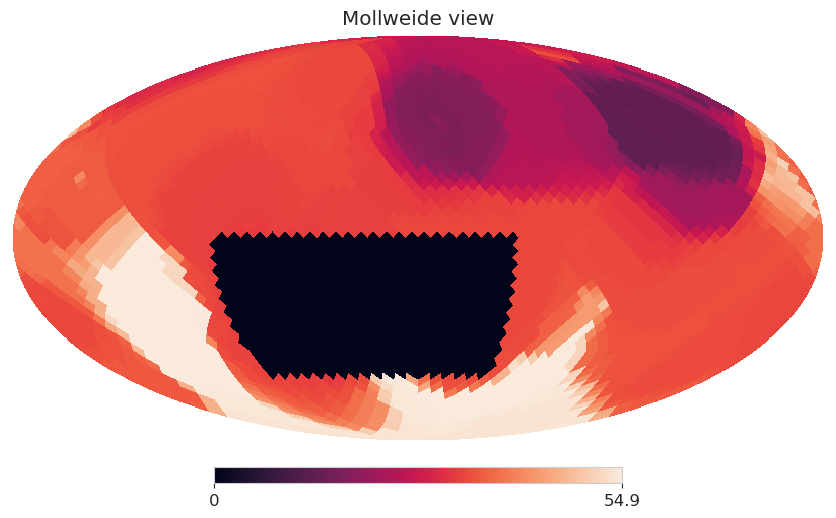

In [ ]:
hp.mollview(FOM_map,flip='geo')

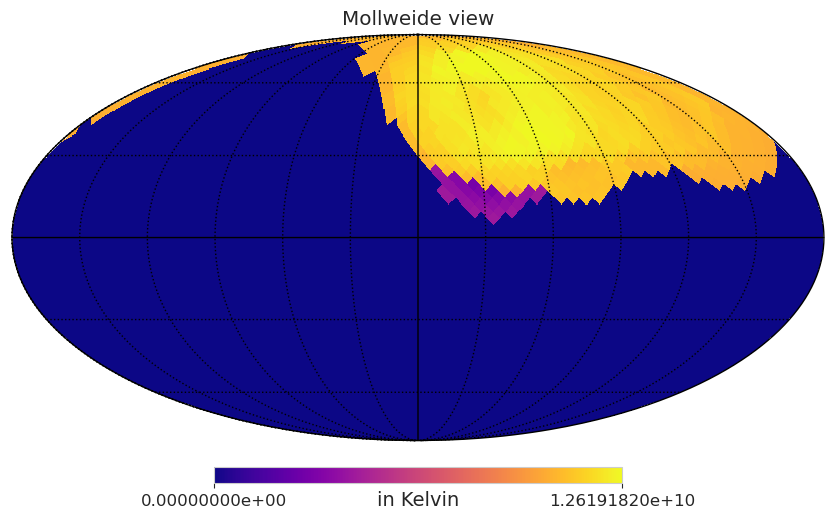

In [ ]:
test_plot1 = np.zeros(hp.nside2npix(nside)) 
test_plot1[0:np.size(power_output[1,:,0])] = power_output[1,:,54]
hp.mollview(test_plot1,cmap='plasma',unit="in Kelvin",norm='hist',flip='geo',format= '%.8e')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/RFI_latestHM.pdf')
plt.show()

In [ ]:
powercube_df=pd.DataFrame(power_output[1,:,:])
# powercube_df.to_csv('/home/saurabhs/Documents/Yogen_starfire/noSynth705.csv')

In [ ]:
np.where(power_output[:,:,])

(array([0, 0, 0, ..., 2, 2, 2]),
 array([   0,    0,    0, ..., 3071, 3071, 3071]),
 array([  0,   5,  44, ..., 216, 217, 225]))